In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [9]:
data = pd.read_csv(r'C:\Users\SriniAchuthan\OneDrive\Desktop\Claude\streaming.csv')
print(data)

         UserID SubscriptionTier  TotalViewingHoursLastMonth     TopGenre  \
0    USER_00001            Basic                        47.9       Comedy   
1    USER_00002          Premium                        41.4        Drama   
2    USER_00003         Standard                        33.6       Action   
3    USER_00004         Standard                       115.6       Action   
4    USER_00005            Basic                        93.8  Documentary   
..          ...              ...                         ...          ...   
495  USER_00496            Basic                        79.6        Drama   
496  USER_00497         Standard                         5.4  Documentary   
497  USER_00498            Basic                        30.0      Romance   
498  USER_00499          Premium                        60.1  Documentary   
499  USER_00500          Premium                        36.2        Drama   

     BingeWatchingSessionsLastMonth  NumberOfUniqueTitlesWatchedLastMonth  

In [10]:
X = data.iloc[:,:-1].values
y = data.iloc[:,-1].values

print(X)

[['USER_00001' 'Basic' 47.9 ... 32.6 3 7.99]
 ['USER_00002' 'Premium' 41.4 ... 45.7 3 17.99]
 ['USER_00003' 'Standard' 33.6 ... 32.3 4 12.99]
 ...
 ['USER_00498' 'Basic' 30.0 ... 51.1 5 7.99]
 ['USER_00499' 'Premium' 60.1 ... 55.5 3 17.99]
 ['USER_00500' 'Premium' 36.2 ... 46.7 4 17.99]]


In [11]:
print(y)

[0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 0 0
 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 1 1 1 0
 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1
 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 1 0 1 0 1
 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 1 0 0 1 1 0 0 1 1 0 1 1 0 0 0 1
 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 1 1 0 0 1 0
 1 1 0 0 1 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 1 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0
 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0
 1 0 1 1 0 1 1 1 0 1 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0
 1 1 0 1 0 1 1 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 0 0 0 1 0 0 0 1 1 1 0
 1 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0
 1 0 0 1 0 0 1 1 0 1 1 1 

Text(0, 0.5, 'BingeWatchingSessionsLastMonth')

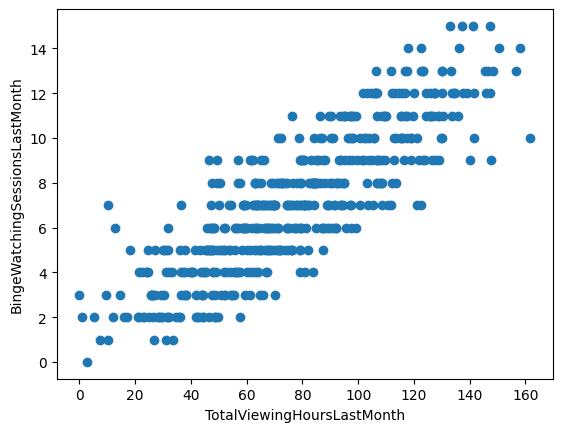

In [12]:
a = data['TotalViewingHoursLastMonth']
b = data['BingeWatchingSessionsLastMonth']
plt.scatter(a,b)
plt.xlabel('TotalViewingHoursLastMonth'
plt.ylabel("BingeWatchingSessionsLastMonth")

In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

from sklearn.linear_model import LogisticRegression


print("=== Dataset ===")
print(data)

# ── 2. Preprocessing ──────────────────────────────────────────────────────────
df = data.copy()
df.drop(columns=["UserID"], inplace=True)

# Encode categorical columns
le = LabelEncoder()
df["SubscriptionTier"] = le.fit_transform(df["SubscriptionTier"])  # Basic=0, Premium=1, Standard=2
df["TopGenre"]         = le.fit_transform(df["TopGenre"])

print("\n=== After Encoding ===")
print(df.head())

# ── 3. Features & Target ──────────────────────────────────────────────────────
X = df.drop(columns=["Churned"])
y = df["Churned"]

print(f"\nFeatures : {X.columns.tolist()}")
print(f"Target   : Churned  (0=Retained, 1=Churned)")
print(f"Class Distribution:\n{y.value_counts().to_string()}")

# ── 4. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

# ── 5. Scale Features ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 6. Train Logistic Regression ──────────────────────────────────────────────
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# ── 7. Predictions ────────────────────────────────────────────────────────────
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

# ── 8. Evaluation ─────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("           MODEL EVALUATION")
print("=" * 50)

print(f"\nAccuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"                 Retained  Churned")
print(f"Actual Retained  {cm[0][0]:<8}  {cm[0][1]}")
print(f"       Churned   {cm[1][0]:<8}  {cm[1][1]}")
print(f"\nTrue  Positives (correctly predicted churn)    : {cm[1][1]}")
print(f"False Positives (predicted churn, was retained): {cm[0][1]}")
print(f"True  Negatives (correctly predicted retained) : {cm[0][0]}")
print(f"False Negatives (missed churn)                 : {cm[1][0]}")

# ── 9. Feature Importance ─────────────────────────────────────────────────────
print("\n--- Feature Importance (Coefficients) ---")
coef_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)
print(coef_df.to_string(index=False))
print("\n(Higher absolute value = stronger influence on churn prediction)")

# ── 10. Sample Predictions ────────────────────────────────────────────────────
print("\n--- Sample Predictions (first 10 test users) ---")
results = X_test.copy().reset_index(drop=True)
results["Actual"]      = y_test.reset_index(drop=True)
results["Predicted"]   = y_pred
results["Churn_Prob%"] = (y_pred_prob * 100).round(1)
results["Correct"]     = results["Actual"] == results["Predicted"]
print(results[["Actual", "Predicted", "Churn_Prob%", "Correct"]].head(10).to_string(index=False))


=== Dataset ===
         UserID SubscriptionTier  TotalViewingHoursLastMonth     TopGenre  \
0    USER_00001            Basic                        47.9       Comedy   
1    USER_00002          Premium                        41.4        Drama   
2    USER_00003         Standard                        33.6       Action   
3    USER_00004         Standard                       115.6       Action   
4    USER_00005            Basic                        93.8  Documentary   
..          ...              ...                         ...          ...   
495  USER_00496            Basic                        79.6        Drama   
496  USER_00497         Standard                         5.4  Documentary   
497  USER_00498            Basic                        30.0      Romance   
498  USER_00499          Premium                        60.1  Documentary   
499  USER_00500          Premium                        36.2        Drama   

     BingeWatchingSessionsLastMonth  NumberOfUniqueTitlesWa